# VEV Options Analysis: Volatility Smile + Detrending

Goal: extract *relative* mispricing across strikes by building a volatility smile and detrending it.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

DATA_DIR = 'round3/'

## Load data

In [3]:
days = [0, 1, 2]
TTE = 5 / 365  # constant for all of round 3
STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VOUCHERS = [f'VEV_{k}' for k in STRIKES]

dfs = []
for d in days:
    df = pd.read_csv(f'{DATA_DIR}prices_round_3_day_{d}.csv', sep=';')
    df['day'] = d
    df['tte'] = TTE
    dfs.append(df)
prices = pd.concat(dfs, ignore_index=True)

dfs = []
for d in days:
    df = pd.read_csv(f'{DATA_DIR}trades_round_3_day_{d}.csv', sep=';')
    df['day'] = d
    df['tte'] = TTE
    dfs.append(df)
trades = pd.concat(dfs, ignore_index=True)
prices['abs_ts'] = prices['day'] * 1_000_000 + prices['timestamp']
trades['abs_ts'] = trades['day'] * 1_000_000 + trades['timestamp']

spot = (prices[prices['product'] == 'VELVETFRUIT_EXTRACT']
        [['day', 'timestamp', 'mid_price']]
        .rename(columns={'mid_price': 'spot'}))
print(f'spot rows: {len(spot)}')
prices.head(3)

spot rows: 30000


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,tte,abs_ts
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0,0.013699,0
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0,0.013699,0
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0,0.013699,0


## Black-Scholes IV

**What is implied volatility (IV)?**

Black-Scholes gives a call option price as a function of: spot S, strike K, time-to-expiry T, risk-free rate r, and *volatility* σ. Everything except σ is observable. So we can *invert*: given the market price of an option, what σ makes B-S match that price? That σ is the **implied volatility** — the market's estimate of future vol baked into that option's price.

We assume r=0 (competition simplification).

In [4]:
def bs_call(S, K, T, sigma):
    """Black-Scholes call price, r=0."""
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * norm.cdf(d2)

def implied_vol(market_price, S, K, T, lo=1e-4, hi=10.0):
    """Brent root-find for IV. Returns NaN if no solution."""
    intrinsic = max(S - K, 0.0)
    if market_price <= intrinsic:
        return np.nan
    try:
        return brentq(lambda s: bs_call(S, K, T, s) - market_price, lo, hi, xtol=1e-6)
    except ValueError:
        return np.nan

# quick sanity check
print(f'BS call(S=5200, K=5000, T=5/365, σ=0.5): {bs_call(5200, 5000, 5/365, 0.5):.2f}')
print(f'IV back-solve: {implied_vol(bs_call(5200, 5000, 5/365, 0.5), 5200, 5000, 5/365):.4f}')

BS call(S=5200, K=5000, T=5/365, σ=0.5): 244.82
IV back-solve: 0.5000


## Compute IV per option per timestamp

In [5]:
opts = prices[prices['product'].isin(VOUCHERS)][['day','timestamp','product','mid_price','tte']].copy()
opts['strike'] = opts['product'].str.extract(r'(\d+)$').astype(int)

opts = opts.merge(spot, on=['day','timestamp'], how='inner')
opts['log_moneyness'] = np.log(opts['spot'] / opts['strike'])  # ln(S/K): 0=ATM, <0=OTM call, >0=ITM
opts['intrinsic'] = np.maximum(opts['spot'] - opts['strike'], 0.0)
opts['extrinsic'] = opts['mid_price'] - opts['intrinsic']

opts['iv'] = opts.apply(
    lambda r: implied_vol(r['mid_price'], r['spot'], r['strike'], r['tte']),
    axis=1
)

In [6]:
# filter deep ITM/OTM: near-zero extrinsic → IV solve explodes (meaningless)
# MIN_EXTRINSIC = 0
# opts_clean = opts[(opts['extrinsic'] >= MIN_EXTRINSIC) & opts['iv'].notna()].copy()
# opts_clean = opts_clean[(opts_clean['product']!='VEV_4000') & (opts_clean['product']!='VEV_4500')].copy()
opts_clean = opts[(opts['iv'].notna())].copy()
print(f'rows kept: {len(opts_clean)} / {len(opts)}')
opts_clean[['product','day','timestamp','spot','strike','log_moneyness','mid_price','extrinsic','iv']].head(10)

rows kept: 251785 / 300000


,product,day,timestamp,spot,strike,log_moneyness,mid_price,extrinsic,iv
0,VEV_5400,0,0,5250.0,5400,-0.028171,23.0,23.0,0.303428
1,VEV_6500,0,0,5250.0,6500,-0.213574,0.5,0.5,0.677302
2,VEV_5500,0,0,5250.0,5500,-0.046520,8.5,8.5,0.303375
3,VEV_5200,0,0,5250.0,5200,0.009569,101.5,51.5,0.302603
4,VEV_5300,0,0,5250.0,5300,-0.009479,53.0,53.0,0.306047
6,VEV_5000,0,0,5250.0,5000,0.048790,257.0,7.0,0.302730
8,VEV_5100,0,0,5250.0,5100,0.028988,171.5,21.5,0.303645
9,VEV_6000,0,0,5250.0,6000,-0.133531,0.5,0.5,0.447033
10,VEV_4500,0,100,5250.5,4500,0.154246,751.0,0.5,0.516363
11,VEV_5000,0,100,5250.5,5000,0.048885,258.0,7.5,0.308482


## The Volatility Smile

**What is the smile?**

If Black-Scholes were the *true* model, all options on the same underlying would have the same IV regardless of strike. In reality they don't — the market prices far OTM and far ITM options at *higher* vol than ATM options. Plot IV vs moneyness and you see a U-shape: the **volatility smile**.

Why does this matter? Because trading the *level* of the smile (e.g. all IVs moved up) is not the same as trading *relative* deviations within the smile (e.g. the 5200 strike is cheap vs its neighbors). We want the latter.

Parabola coeffs: a=9.2536, b=0.0234, c=0.2677


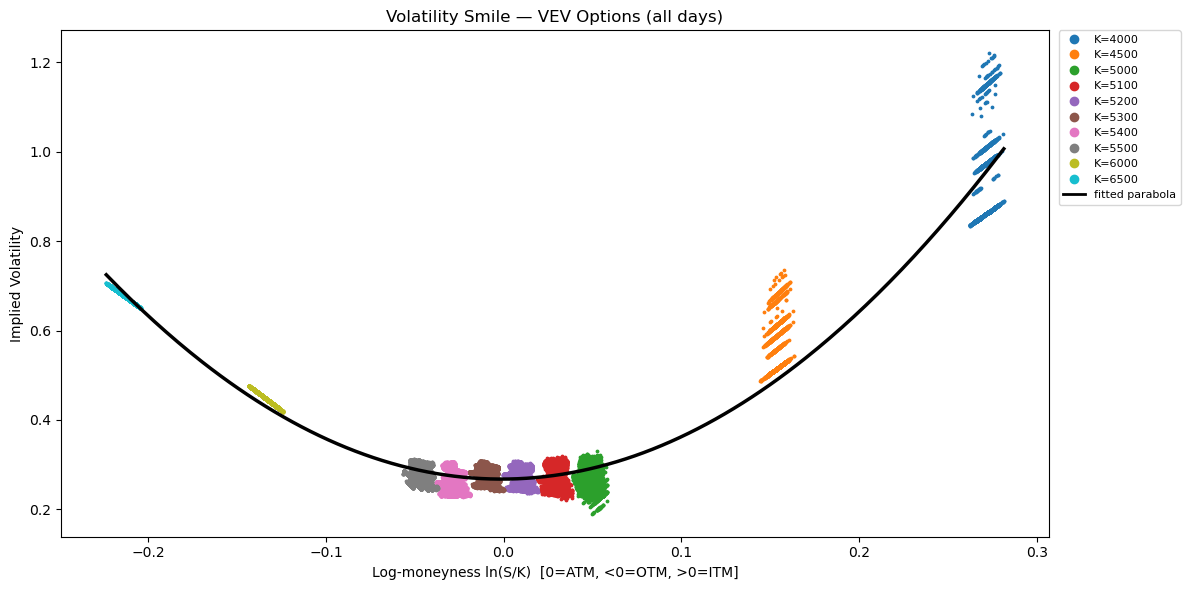

In [7]:
STRIKE_COLORS = plt.cm.tab10(np.linspace(0, 1, len(STRIKES)))
strike_color = dict(zip(STRIKES, STRIKE_COLORS))

fig, ax = plt.subplots(figsize=(12, 6))

for k in STRIKES:
    sub = opts_clean[opts_clean['strike'] == k]
    ax.scatter(sub['log_moneyness'], sub['iv'], alpha=1, s=3,
               color=strike_color[k], label=f'K={k}')

x_all = opts_clean['log_moneyness'].values
y_all = opts_clean['iv'].values
coeffs = np.polyfit(x_all, y_all, 2)
x_grid = np.linspace(x_all.min(), x_all.max(), 300)
ax.plot(x_grid, np.polyval(coeffs, x_grid), 'k-', lw=2.5, label='fitted parabola')
print(f'Parabola coeffs: a={coeffs[0]:.4f}, b={coeffs[1]:.4f}, c={coeffs[2]:.4f}')

ax.set_xlabel('Log-moneyness ln(S/K)  [0=ATM, <0=OTM, >0=ITM]')
ax.set_ylabel('Implied Volatility')
ax.set_title('Volatility Smile — VEV Options (all days)')
handles = [plt.Line2D([0],[0], color=strike_color[k], marker='o', ls='', label=f'K={k}') for k in STRIKES]
handles.append(plt.Line2D([0],[0], color='k', lw=2, label='fitted parabola'))
ax.legend(handles=handles, fontsize=8, ncol=1, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

## Parabola Fit + Detrending

**Why fit a parabola?**

The smile curve is smooth and roughly quadratic in moneyness. By fitting `IV ≈ a*(moneyness)² + b*(moneyness) + c`, we capture the *structural* component — the expected IV at each moneyness level.

**Detrending**: subtract the fitted value from observed IV.
```
residual_IV = observed_IV - parabola_fit(moneyness)
```
Residuals have the smile shape removed. A positive residual means "this option's IV is higher than the smile predicts" → option is *relatively expensive* → candidate to sell. Negative residual → relatively cheap → candidate to buy.

This is powerful because it removes the confound: without detrending, an ITM option always has higher IV than ATM, making raw IV comparisons misleading. After detrending, you're comparing apples to apples.

In [8]:
# Use the same global parabola fitted above
# residual = observed IV - parabola(log_moneyness)
opts_clean = opts_clean.copy()
opts_clean['iv_fit'] = np.polyval(coeffs, opts_clean['log_moneyness'].values)
opts_clean['iv_resid'] = opts_clean['iv'] - opts_clean['iv_fit']
print('done. sample:')
opts_clean[['product','day','timestamp','log_moneyness','iv','iv_fit','iv_resid']].head(10)

done. sample:


,product,day,timestamp,log_moneyness,iv,iv_fit,iv_resid
0,VEV_5400,0,0,-0.028171,0.303428,0.274390,0.029038
1,VEV_6500,0,0,-0.213574,0.677302,0.684802,-0.007499
2,VEV_5500,0,0,-0.046520,0.303375,0.286643,0.016732
3,VEV_5200,0,0,0.009569,0.302603,0.268777,0.033826
4,VEV_5300,0,0,-0.009479,0.306047,0.268315,0.037732
6,VEV_5000,0,0,0.048790,0.302730,0.290875,0.011855
8,VEV_5100,0,0,0.028988,0.303645,0.276159,0.027485
9,VEV_6000,0,0,-0.133531,0.447033,0.429579,0.017454
10,VEV_4500,0,100,0.154246,0.516363,0.491472,0.024890
11,VEV_5000,0,100,0.048885,0.308482,0.290963,0.017519


## Plot detrended IV (residuals)

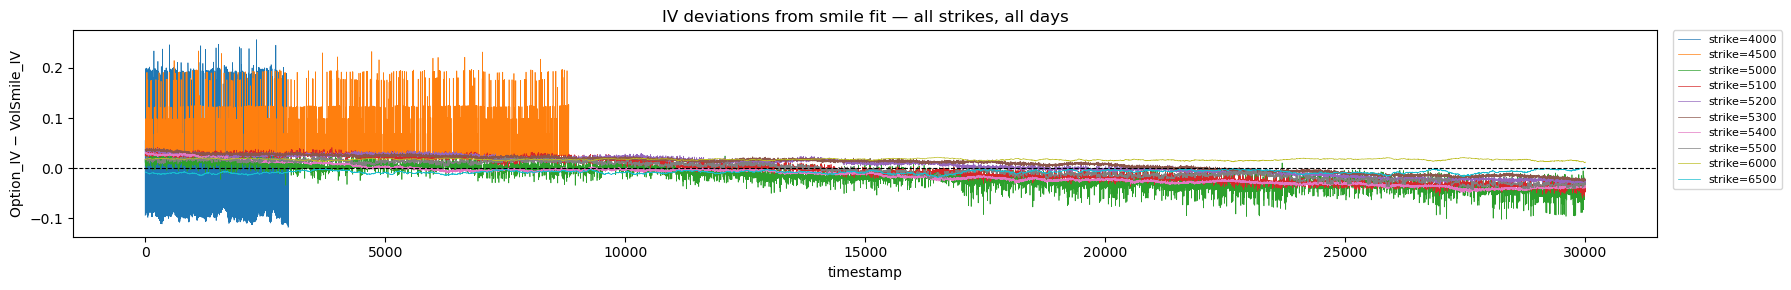

In [9]:
fig, ax = plt.subplots(figsize=(18, 3))

for k in STRIKES:
    sub = (opts_clean[opts_clean['strike'] == k]
           .sort_values(['day', 'timestamp'])
           .copy())
    sub = sub.reset_index(drop=True)
    ax.plot(sub.index, sub['iv_resid'], lw=0.5, alpha=1,
            color=strike_color[k], label=f'strike={k}')

ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('timestamp')
ax.set_ylabel('Option_IV − VolSmile_IV')
ax.set_title('IV deviations from smile fit — all strikes, all days')
ax.legend(fontsize=8, ncol=1, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

## Price Deviations over Time

Convert IV residuals → price space: `price_dev = mid_price - BS(spot, K, T, iv_fit)`.
Positive = option trading above fair value → sell. Negative → buy.

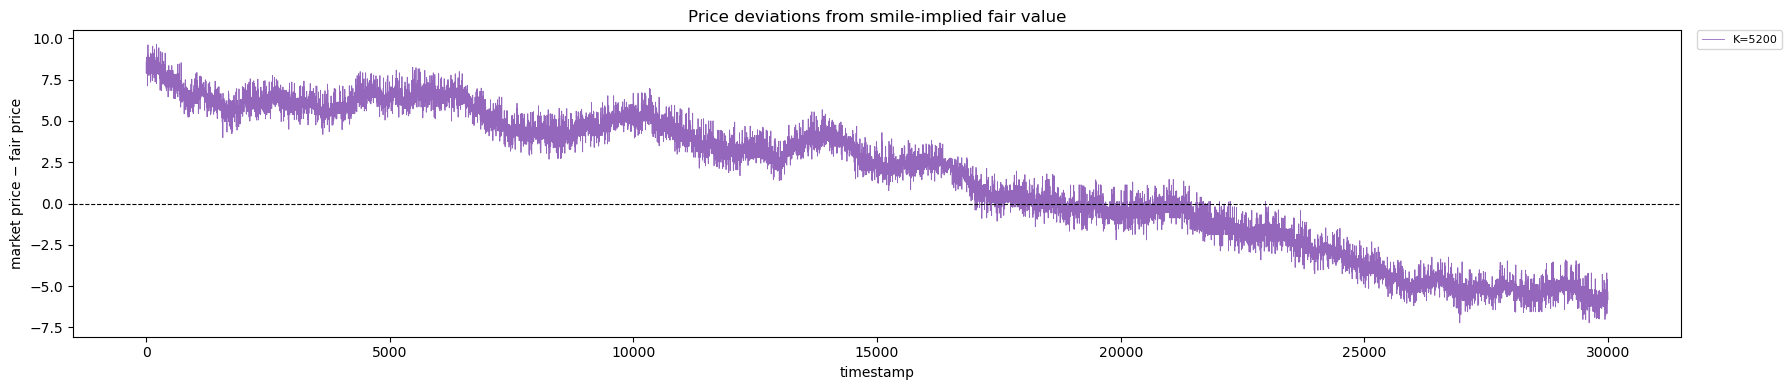

In [10]:
# add more strikes to this list to compare
# FOCUS_STRIKES = [5000,5100,5200,5300,5400,5500]
FOCUS_STRIKES = [5200]

opts_clean['fair_price'] = opts_clean.apply(
    lambda r: bs_call(r['spot'], r['strike'], r['tte'], r['iv_fit']), axis=1
)
opts_clean['price_dev'] = opts_clean['mid_price'] - opts_clean['fair_price']

fig, ax = plt.subplots(figsize=(18, 4))

for k in FOCUS_STRIKES:
    sub = (opts_clean[opts_clean['strike'] == k]
           .sort_values(['day', 'timestamp'])
           .reset_index(drop=True))
    ax.plot(sub.index, sub['price_dev'], lw=0.6,
            color=strike_color[k], label=f'K={k}')

ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('timestamp')
ax.set_ylabel('market price − fair price')
ax.set_title('Price deviations from smile-implied fair value')
ax.legend(fontsize=8, ncol=1, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

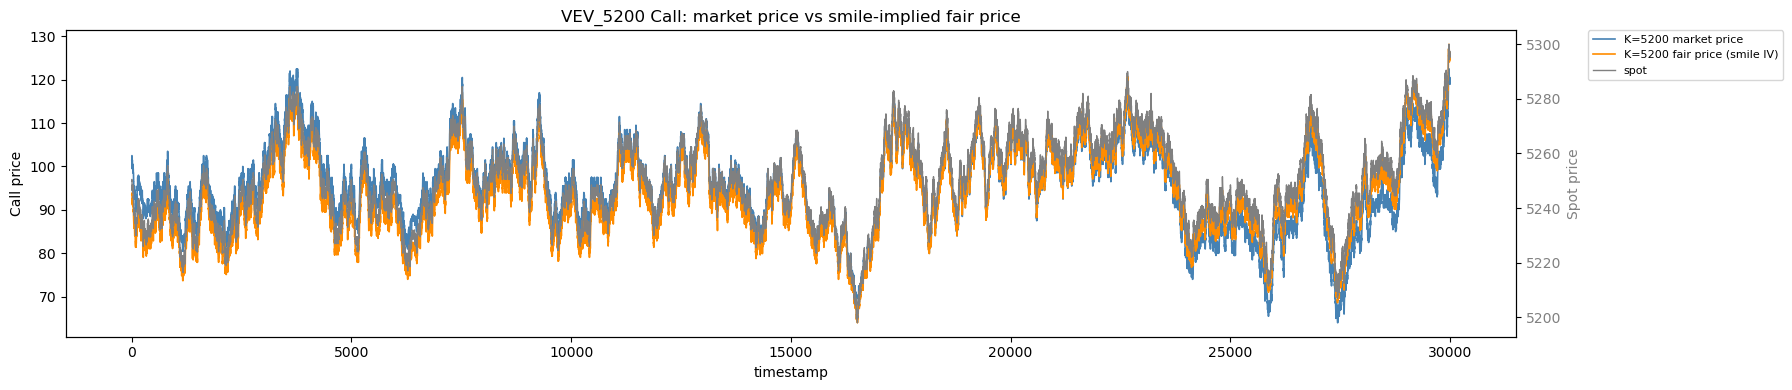

In [11]:
PLOT_STRIKE = 5200  # change to explore other strikes

X_LIM = None   # e.g. (0, 5000)
Y_LIM = None   # set to override; auto-zooms to X_LIM range when None

sub = (opts_clean[opts_clean['strike'] == PLOT_STRIKE]
       .sort_values(['day', 'timestamp'])
       .reset_index(drop=True))

fig, ax1 = plt.subplots(figsize=(18, 4))

ax1.plot(sub.index, sub['mid_price'], lw=1.2, color='steelblue', label=f'K={PLOT_STRIKE} market price')
ax1.plot(sub.index, sub['fair_price'], lw=1.2, color='darkorange', label=f'K={PLOT_STRIKE} fair price (smile IV)')
ax1.set_ylabel('Call price')
ax1.set_xlabel('timestamp')
ax1.set_title(f'VEV_{PLOT_STRIKE} Call: market price vs smile-implied fair price')

if X_LIM:
    ax1.set_xlim(X_LIM)
    if Y_LIM is None:
        mask = (sub.index >= X_LIM[0]) & (sub.index <= X_LIM[1])
        visible = pd.concat([sub.loc[mask, 'mid_price'], sub.loc[mask, 'fair_price']]).dropna()
        if len(visible):
            pad = (visible.max() - visible.min()) * 0.05
            ax1.set_ylim(visible.min() - pad, visible.max() + pad)
if Y_LIM:
    ax1.set_ylim(Y_LIM)

ax2 = ax1.twinx()
spot_ts = spot.sort_values(['day', 'timestamp']).reset_index(drop=True)
ax2.plot(spot_ts.index, spot_ts['spot'], lw=1, color='grey', alpha=1, label='spot')
ax2.set_ylabel('Spot price', color='grey')
ax2.tick_params(axis='y', labelcolor='grey')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8,
           bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

[2 1] 18


<Axes: >

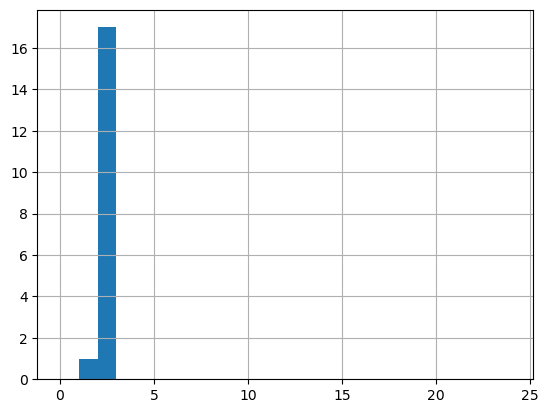

In [12]:
strike = '5200'
ticker = f'VEV_{strike}'
option_prices = prices[prices['product'] == ticker]
option_trades = trades[trades['symbol'] == ticker]
tmp = option_prices[option_prices['abs_ts'].isin(option_trades['abs_ts'])]# & ipr_trades['price'] == ipr_prices['bid_price_1']]
spreads = tmp.ask_price_1 - tmp.bid_price_1
print(spreads.unique(), len(spreads))
spreads.hist(bins=np.arange(0,25,1))

# For 4000, the spread is either (10, 11, 20, 21, 22). The distribution is heavily in favor of 21 (basically only 21)
# For 4500, there was one trade and the srpead was 7
# For 5000, there was one trade and the spread was 2
# For 5100, there was one trade and the spread was 2
# For 5200, there were 18 trades and all but one of them had a spread of 2 (the rest were 1)
# For 5300, there were 121 trades and basically all of them had a spread of 2 (the rest were 1)
# For 5400, there were 225 trades and around 2/3 of them had a spread of 1 (the rest were 2)
# For 5500, there were 267 trades; pretty much all of them had a spread of 1
# For 6000, all 284 trades happened at a spread of 1
# Same for 6500; curious ...

<Axes: >

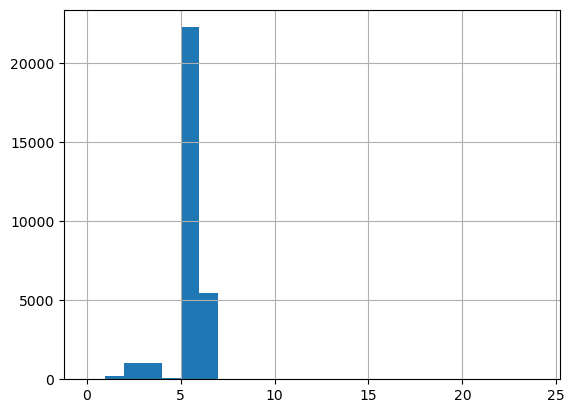

In [13]:
ticker = f'VELVETFRUIT_EXTRACT'
ticker_prices = prices[prices['product'] == ticker]
ticker_trades = trades[trades['symbol'] == ticker]
tmp = ticker_prices[ticker_prices['abs_ts'].isin(ticker_trades['abs_ts'])]# & ipr_trades['price'] == ipr_prices['bid_price_1']]
spreads = ticker_prices.ask_price_1 - ticker_prices.bid_price_1
spreads.hist(bins=np.arange(0,25,1))

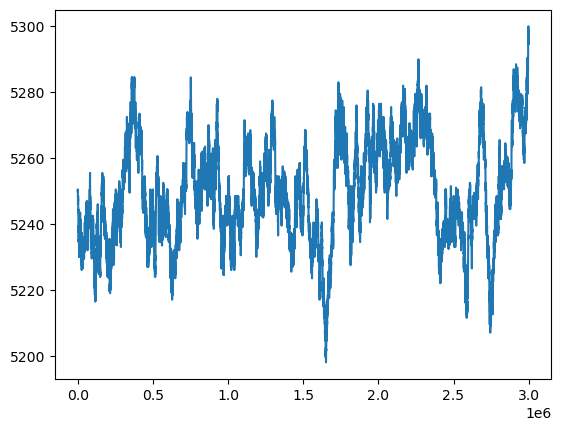

In [14]:
plt.plot(ticker_prices.abs_ts, ticker_prices.mid_price)

In [15]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
import seaborn as sns

def plot_joint_dynamics(strike_list):
    """
    Plots the underlying price vs specific option strikes.
    df_prices: DataFrame with timestamp, underlying_mid, and various strike mid-prices.
    """
    fig, axes = plt.subplots(len(strike_list), 1, figsize=(12, 4 * len(strike_list)), sharex=True)
    
    if len(strike_list) == 1: axes = [axes]

    for i, strike in enumerate(strike_list):
        ax_underlying = axes[i]
        ax_option = ax_underlying.twinx()
        
        ln1 = ax_underlying.plot(prices['abs_ts'].unique(), prices[prices['product'] == 'VELVETFRUIT_EXTRACT'].mid_price, 
                                 color='blue', label=f'Underlying', alpha=0.6)
        ln2 = ax_option.plot(prices['abs_ts'].unique(), prices[prices['product'] == f'VEV_{strike}'].mid_price, 
                             color='orange', label=f'Call {strike}')
        
        ax_underlying.set_ylabel('Underlying Price')
        ax_option.set_ylabel(f'Call {strike} Price')
        
        # Combine legends
        lns = ln1 + ln2
        labs = [l.get_label() for l in lns]
        ax_underlying.legend(lns, labs, loc='upper left')
        
    plt.title("Joint Underlying and Option Price Dynamics")
    plt.tight_layout()
    plt.show()

def plot_empirical_delta(strike):
    """
    Visualizes the 'Real' Delta by plotting Option Price vs Underlying Price.
    """
    plt.figure(figsize=(8, 6))
    tmp = pd.DataFrame({f'VEV_{strike}' : list(prices[prices['product'] == f'VEV_{strike}'].mid_price),
                        'VELVETFRUIT_EXTRACT' : list(prices[prices['product'] == 'VELVETFRUIT_EXTRACT'].mid_price)})
    print(tmp.head())
    
    sns.regplot(x='VELVETFRUIT_EXTRACT', y=f'VEV_{strike}', data=tmp, 
                scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'Empirical Delta: Call {strike} vs. Underlying')
    plt.xlabel('Underlying Price')
    plt.ylabel('Option Price')
    plt.show()

   VEV_5400  VELVETFRUIT_EXTRACT
0      23.0               5250.0
1      23.5               5250.5
2      23.5               5250.5
3      23.5               5250.5
4      23.5               5250.5


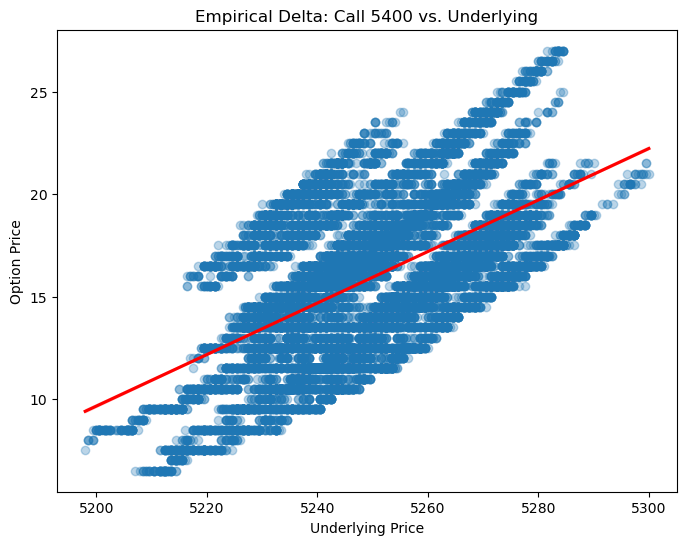

In [16]:
#plot_joint_dynamics(strike_list=[5000, 5200, 5400])
plot_empirical_delta(5400)

   VEV_6000  VELVETFRUIT_EXTRACT
0       0.5               5250.0
1       0.5               5250.5
2       0.5               5250.5
3       0.5               5250.5
4       0.5               5250.5


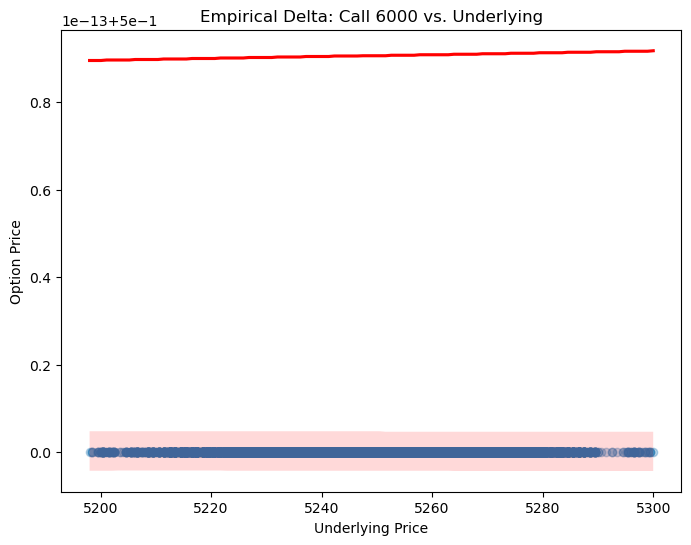

In [17]:
plot_empirical_delta(6000)

## Regime check 1: ATM IV over time

If ATM IV trends across the session, residual drift is mostly **level shift**, not smile-shape rotation. Easier to handle: subtract a running ATM IV baseline.

ATM IV = IV of strike nearest to spot at each timestamp.

   day  timestamp  atm_strike    spot    atm_iv
0    0          0        5300  5250.0  0.306047
1    0        100        5300  5250.5  0.305200
2    0        200        5300  5250.5  0.305200
3    0        300        5300  5250.5  0.305200
4    0        400        5300  5250.5  0.305200
ATM rows: 30000


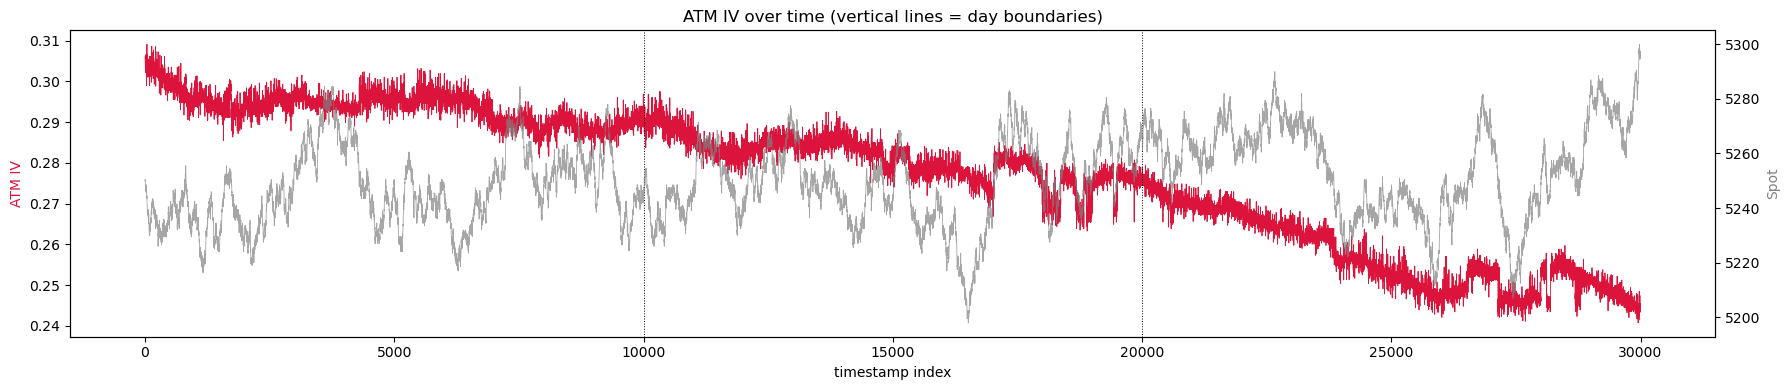

ATM IV mean=0.2772  std=0.0165
  day 0 mean=0.2937
  day 1 mean=0.2808
  day 2 mean=0.2572


In [18]:
# pick nearest strike to spot at each timestamp, take its IV
opts_clean['abs_lm'] = opts_clean['log_moneyness'].abs()
atm = (opts_clean
       .sort_values(['day','timestamp','abs_lm'])
       .groupby(['day','timestamp'], as_index=False)
       .first()[['day','timestamp','strike','spot','iv']]
       .rename(columns={'iv':'atm_iv','strike':'atm_strike'}))
atm = atm.sort_values(['day','timestamp']).reset_index(drop=True)
print(atm.head())
print(f'ATM rows: {len(atm)}')

fig, ax1 = plt.subplots(figsize=(18, 4))
ax1.plot(atm.index, atm['atm_iv'], lw=0.6, color='crimson', label='ATM IV')
ax1.set_ylabel('ATM IV', color='crimson')
ax1.set_xlabel('timestamp index')
ax2 = ax1.twinx()
ax2.plot(atm.index, atm['spot'], lw=0.6, color='grey', alpha=0.7, label='spot')
ax2.set_ylabel('Spot', color='grey')
for d in [10000, 20000]:
    ax1.axvline(d, color='k', ls=':', lw=0.7)
ax1.set_title('ATM IV over time (vertical lines = day boundaries)')
plt.tight_layout()
plt.show()

print(f'ATM IV mean={atm.atm_iv.mean():.4f}  std={atm.atm_iv.std():.4f}')
print(f'  day 0 mean={atm[atm.day==0].atm_iv.mean():.4f}')
print(f'  day 1 mean={atm[atm.day==1].atm_iv.mean():.4f}')
print(f'  day 2 mean={atm[atm.day==2].atm_iv.mean():.4f}')

## Regime check 2: residual vs spot (sticky-strike test)

Hypothesis: smile is **sticky-strike** (each strike's IV stays anchored to its $K$, not its moneyness). Then when spot moves, `ln(S/K)` shifts → fitted IV moves → residual gets correlated with spot even though true IV per strike is unchanged.

Test: scatter `iv_resid` vs `spot` per strike. Strong slope → switch x-axis from `ln(S/K)` to `K` (or `K-S`).

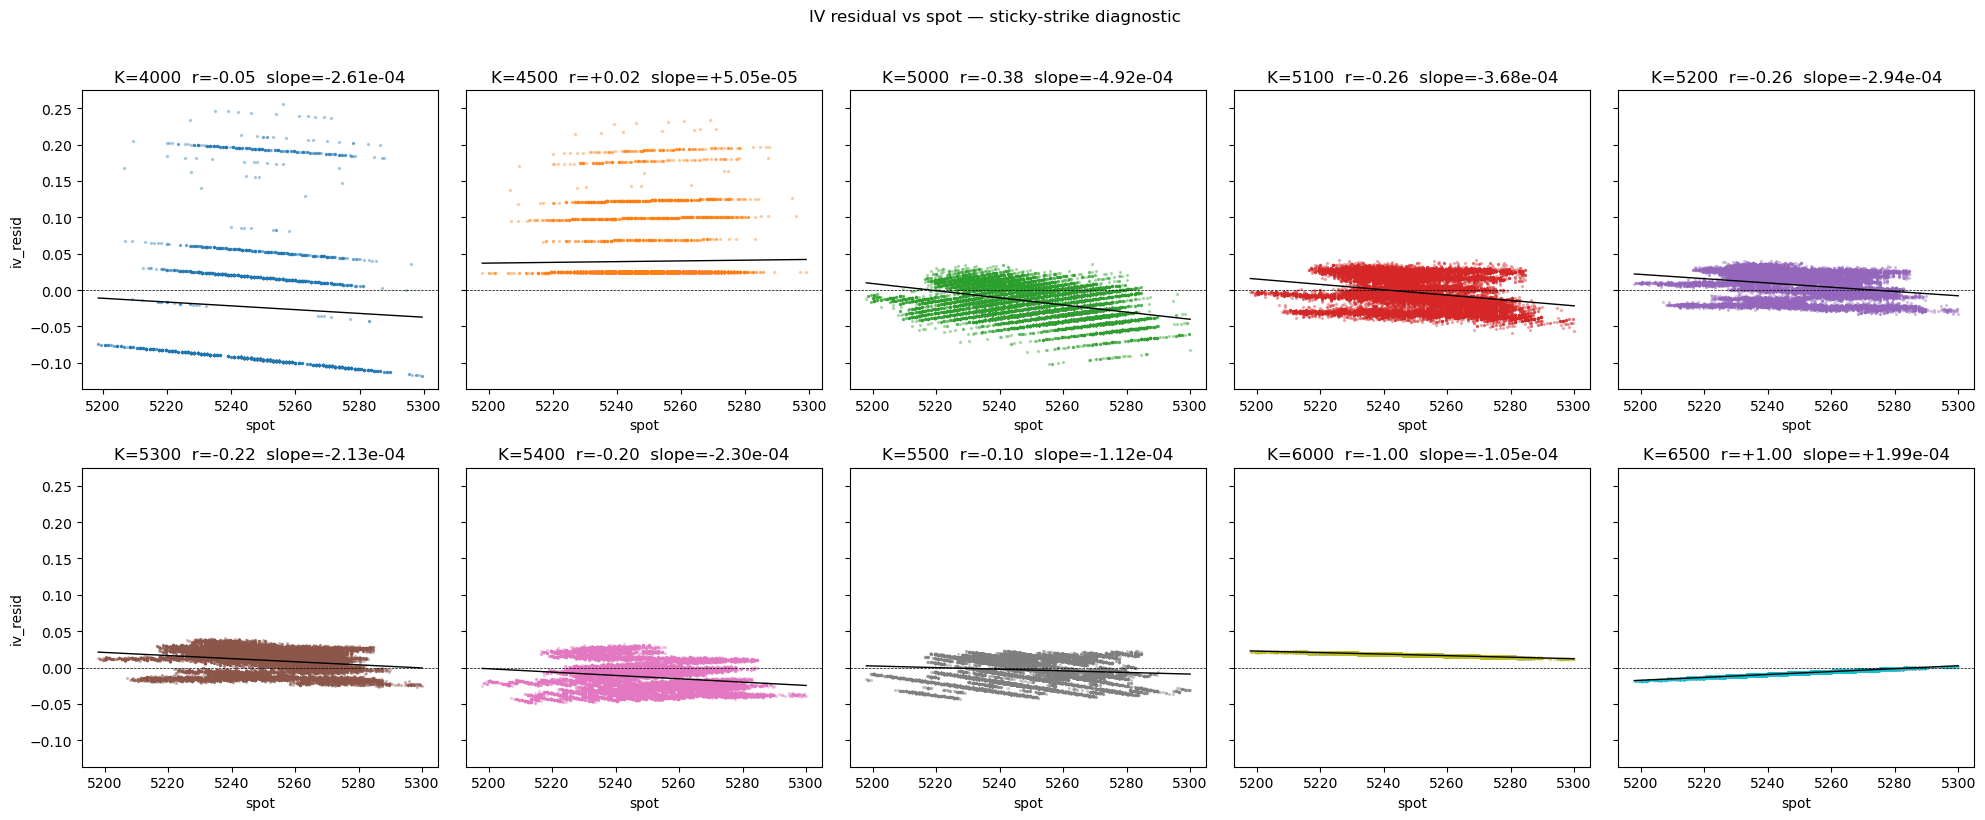

In [19]:
from scipy.stats import pearsonr

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
axes = axes.flatten()
for ax, k in zip(axes, STRIKES):
    sub = opts_clean[opts_clean['strike'] == k]
    if len(sub) < 50:
        ax.set_title(f'K={k} (n={len(sub)})')
        continue
    ax.scatter(sub['spot'], sub['iv_resid'], s=2, alpha=0.3, color=strike_color[k])
    r, _ = pearsonr(sub['spot'], sub['iv_resid'])
    slope = np.polyfit(sub['spot'], sub['iv_resid'], 1)[0]
    xg = np.linspace(sub['spot'].min(), sub['spot'].max(), 50)
    ax.plot(xg, np.polyval(np.polyfit(sub['spot'], sub['iv_resid'], 1), xg), 'k-', lw=1)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_title(f'K={k}  r={r:+.2f}  slope={slope:+.2e}')
    ax.set_xlabel('spot')
axes[0].set_ylabel('iv_resid')
axes[5].set_ylabel('iv_resid')
plt.suptitle('IV residual vs spot — sticky-strike diagnostic', y=1.02)
plt.tight_layout()
plt.show()

## Regime check 3: refit smile on $K$ instead of $\ln(S/K)$

If the above showed sticky-strike, refit `IV ≈ f(K)` directly. Strike is fixed → no spot-driven contamination.

K-space parabola: a=3.281e-07, b=-3.512e-03, c=9.662e+00


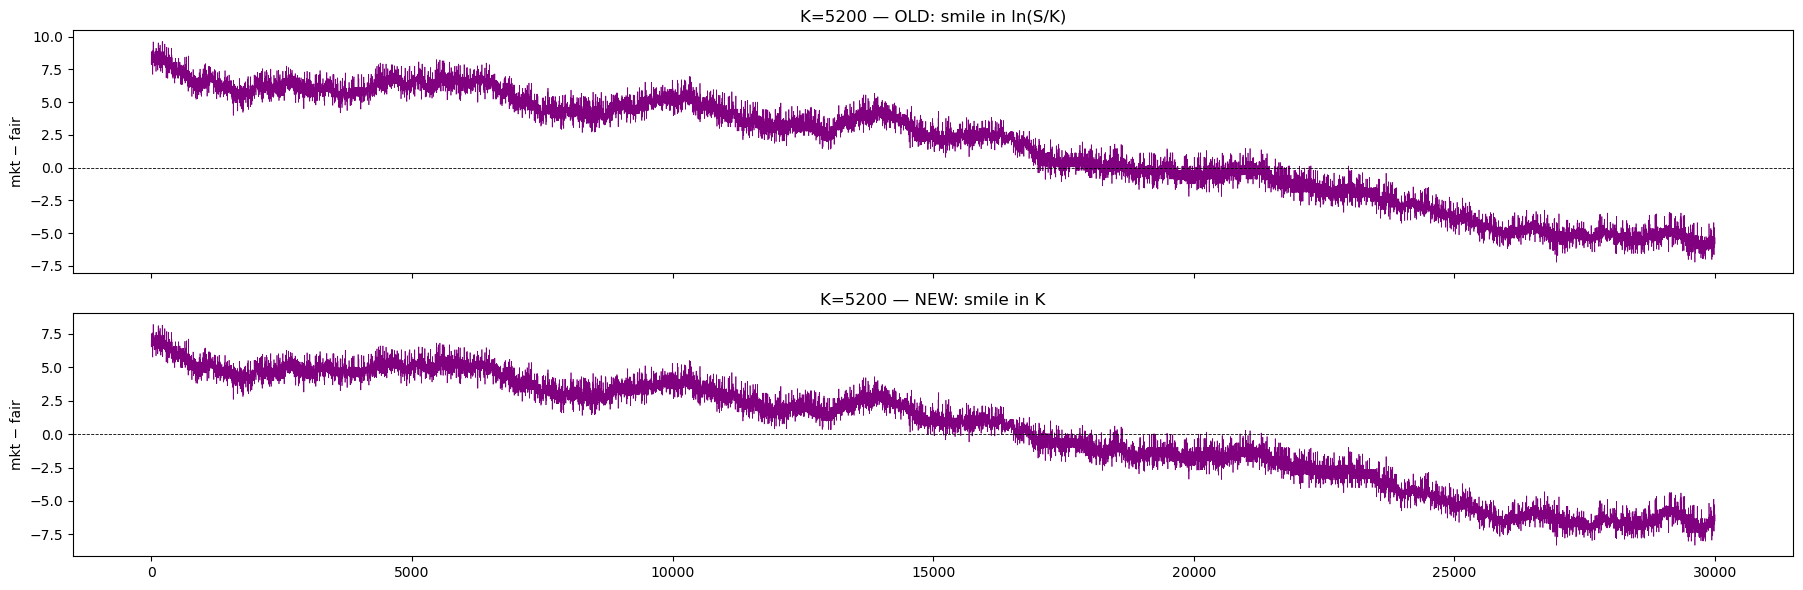

In [20]:
# parabola in K-space
xK = opts_clean['strike'].values.astype(float)
yK = opts_clean['iv'].values
coeffs_K = np.polyfit(xK, yK, 2)
print(f'K-space parabola: a={coeffs_K[0]:.3e}, b={coeffs_K[1]:.3e}, c={coeffs_K[2]:.3e}')

opts_K = opts_clean.copy()
opts_K['iv_fit_K'] = np.polyval(coeffs_K, opts_K['strike'].values)
opts_K['iv_resid_K'] = opts_K['iv'] - opts_K['iv_fit_K']
opts_K['fair_price_K'] = opts_K.apply(
    lambda r: bs_call(r['spot'], r['strike'], r['tte'], r['iv_fit_K']), axis=1)
opts_K['price_dev_K'] = opts_K['mid_price'] - opts_K['fair_price_K']

# compare price_dev vs price_dev_K for K=5200
fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True)
for ax, col, title in [
    (axes[0], 'price_dev',   'OLD: smile in ln(S/K)'),
    (axes[1], 'price_dev_K', 'NEW: smile in K')
]:
    sub = (opts_K[opts_K['strike']==5200].sort_values(['day','timestamp']).reset_index(drop=True))
    ax.plot(sub.index, sub[col], lw=0.5, color='purple')
    ax.axhline(0, color='k', lw=0.6, ls='--')
    ax.set_title(f'K=5200 — {title}')
    ax.set_ylabel('mkt − fair')
plt.tight_layout()
plt.show()

## Per-day parabola refit

Global parabola averages 3 regimes (ATM IV: 0.294 → 0.281 → 0.257). Refit one parabola per day → kills level-shift drift.

In [21]:
# per-day parabola fit
coeffs_per_day = {}
for d in days:
    sub = opts_clean[opts_clean['day'] == d]
    coeffs_per_day[d] = np.polyfit(sub['log_moneyness'].values, sub['iv'].values, 2)
    a, b, c = coeffs_per_day[d]
    print(f'day {d}: a={a:.4f}, b={b:+.4f}, c={c:.4f}')

# apply per-day fit
def fit_row(r):
    a, b, c = coeffs_per_day[r['day']]
    return a*r['log_moneyness']**2 + b*r['log_moneyness'] + c

opts_clean['iv_fit_pd'] = (
    coeffs_per_day_arr := np.array([coeffs_per_day[d] for d in opts_clean['day'].values])
)[:,0] * opts_clean['log_moneyness'].values**2 + \
    coeffs_per_day_arr[:,1] * opts_clean['log_moneyness'].values + \
    coeffs_per_day_arr[:,2]
opts_clean['iv_resid_pd'] = opts_clean['iv'] - opts_clean['iv_fit_pd']
opts_clean['fair_price_pd'] = opts_clean.apply(
    lambda r: bs_call(r['spot'], r['strike'], r['tte'], r['iv_fit_pd']), axis=1)
opts_clean['price_dev_pd'] = opts_clean['mid_price'] - opts_clean['fair_price_pd']

# stats
print('\nresidual stats by strike (per-day fit):')
print(opts_clean.groupby('strike')['price_dev_pd'].agg(['mean','std','min','max']).round(2))

day 0: a=8.8553, b=+0.0489, c=0.2867
day 1: a=9.2472, b=+0.0277, c=0.2687
day 2: a=9.6627, b=-0.0056, c=0.2478

residual stats by strike (per-day fit):
        mean   std   min   max
strike                        
4000    0.03  1.29 -1.08  5.65
4500    0.41  0.67  0.08  5.27
5000   -1.20  0.72 -4.38  2.57
5100   -0.46  1.41 -4.51  4.18
5200    1.57  1.64 -2.72  6.72
5300    2.37  1.46 -1.74  7.61
5400   -2.16  1.41 -4.95  2.41
5500   -0.29  0.66 -2.04  1.51
6000    0.15  0.05  0.04  0.23
6500   -0.06  0.03 -0.19  0.02


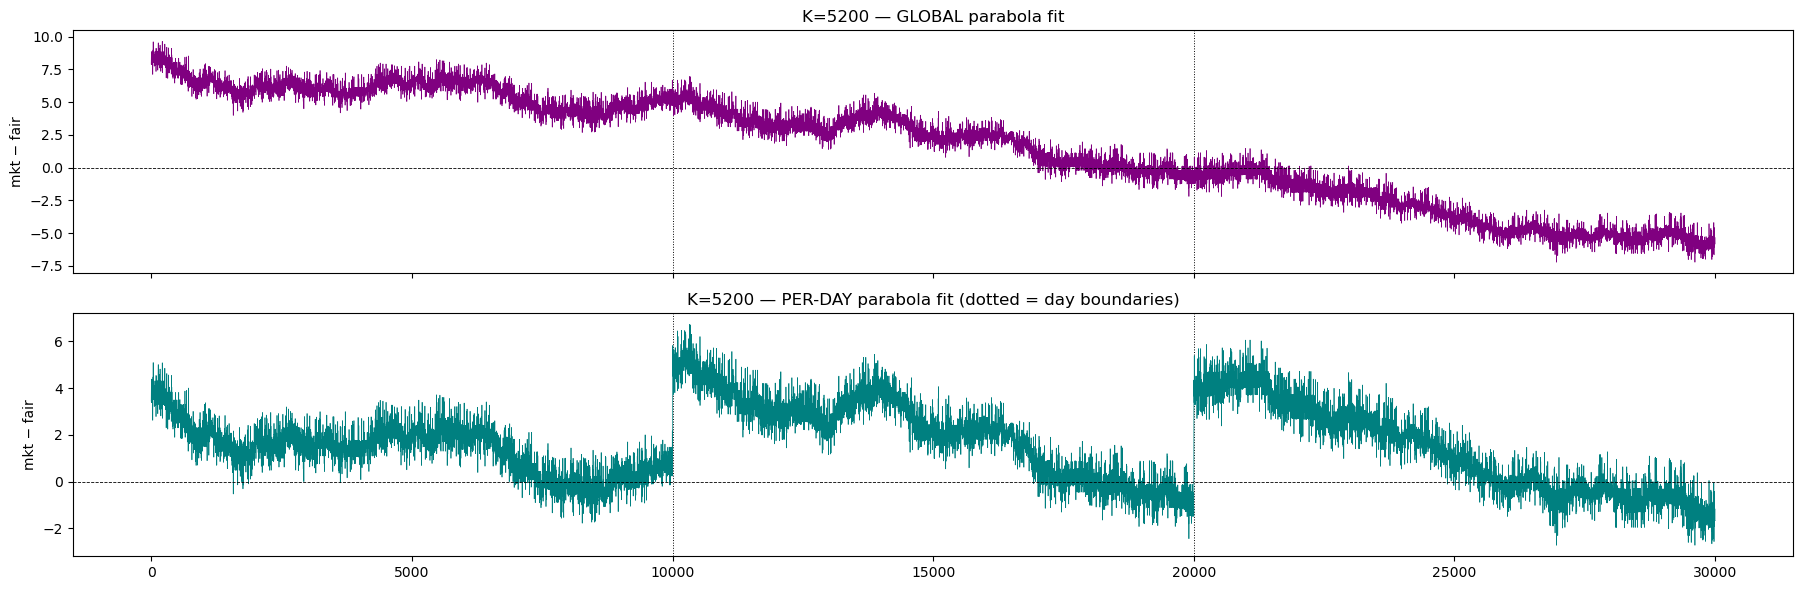

global  K=5200 price_dev: mean=+1.611  std=4.118
per-day K=5200 price_dev: mean=+1.572  std=1.638

per-day residual mean by day (K=5200):
      mean    std
day              
0    1.375  1.030
1    2.064  1.738
2    1.279  1.898


In [22]:
# compare global vs per-day price_dev for K=5200
fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True)
sub = (opts_clean[opts_clean['strike']==5200]
       .sort_values(['day','timestamp']).reset_index(drop=True))
for ax in axes:
    for x in [10000, 20000]:
        ax.axvline(x, color='k', ls=':', lw=0.7)
axes[0].plot(sub.index, sub['price_dev'],    lw=0.5, color='purple')
axes[0].axhline(0, color='k', lw=0.6, ls='--')
axes[0].set_title('K=5200 — GLOBAL parabola fit')
axes[0].set_ylabel('mkt − fair')
axes[1].plot(sub.index, sub['price_dev_pd'], lw=0.5, color='teal')
axes[1].axhline(0, color='k', lw=0.6, ls='--')
axes[1].set_title('K=5200 — PER-DAY parabola fit (dotted = day boundaries)')
axes[1].set_ylabel('mkt − fair')
plt.tight_layout(); plt.show()

print(f'global  K=5200 price_dev: mean={sub.price_dev.mean():+.3f}  std={sub.price_dev.std():.3f}')
print(f'per-day K=5200 price_dev: mean={sub.price_dev_pd.mean():+.3f}  std={sub.price_dev_pd.std():.3f}')
print('\nper-day residual mean by day (K=5200):')
print(sub.groupby('day')['price_dev_pd'].agg(['mean','std']).round(3))

## Rolling window parabola refit

Window W=5000 timestamps. At each ts t, fit parabola on rows where ts_idx ∈ (t-W, t]. Closed-form via running sums of (x^k) and (x^k · y), k=0..4 / 0..2. O(T) total.

Warmup (t < W): use global `coeffs` as prior.

In [23]:
W = 5000  # rolling window in timestamp units

# build ts_idx: monotonic across days. ts steps = 100 → 10000 per day
opts_clean['ts_idx'] = (opts_clean['day']*10000 + (opts_clean['timestamp']//100)).astype(int)

x = opts_clean['log_moneyness'].values
y = opts_clean['iv'].values
opts_clean['_x0'] = 1.0
opts_clean['_x1'] = x
opts_clean['_x2'] = x**2
opts_clean['_x3'] = x**3
opts_clean['_x4'] = x**4
opts_clean['_y0'] = y
opts_clean['_y1'] = x * y
opts_clean['_y2'] = (x**2) * y

agg_cols = ['_x0','_x1','_x2','_x3','_x4','_y0','_y1','_y2']
per_ts = opts_clean.groupby('ts_idx')[agg_cols].sum()
full_idx = np.arange(per_ts.index.min(), per_ts.index.max()+1)
per_ts = per_ts.reindex(full_idx, fill_value=0.0)

# rolling sum: t < W → cumsum[t] (expanding); t ≥ W → cumsum[t] - cumsum[t-W]
csum = per_ts.cumsum()
shifted = csum.shift(W).fillna(0.0)
rolling = csum - shifted

T = len(rolling)
M = np.zeros((T, 3, 3))
M[:,0,0] = rolling['_x0']; M[:,0,1] = rolling['_x1']; M[:,0,2] = rolling['_x2']
M[:,1,0] = rolling['_x1']; M[:,1,1] = rolling['_x2']; M[:,1,2] = rolling['_x3']
M[:,2,0] = rolling['_x2']; M[:,2,1] = rolling['_x3']; M[:,2,2] = rolling['_x4']
B = rolling[['_y0','_y1','_y2']].values

# solve all rows. lstsq fallback for any singular (very small t with collinear strikes).
coeffs_roll = np.empty((T, 3))
try:
    sol = np.linalg.solve(M, B[:,:,None])[:,:,0]  # [c, b, a]
    coeffs_roll = sol[:, ::-1]
except np.linalg.LinAlgError:
    for i in range(T):
        try:
            s = np.linalg.solve(M[i], B[i])
        except np.linalg.LinAlgError:
            s, *_ = np.linalg.lstsq(M[i], B[i], rcond=None)
        coeffs_roll[i] = s[::-1]

print(f'rolling fits computed: {T} timestamps (expanding for t<{W}, rolling W={W} after)')
print(f'coeffs at t=10:    a={coeffs_roll[10,0]:.4f}, b={coeffs_roll[10,1]:+.4f}, c={coeffs_roll[10,2]:.4f}')
print(f'coeffs at t={W}: a={coeffs_roll[W,0]:.4f}, b={coeffs_roll[W,1]:+.4f}, c={coeffs_roll[W,2]:.4f}')
print(f'coeffs at t={T-1}: a={coeffs_roll[-1,0]:.4f}, b={coeffs_roll[-1,1]:+.4f}, c={coeffs_roll[-1,2]:.4f}')

rolling fits computed: 30000 timestamps (expanding for t<5000, rolling W=5000 after)
coeffs at t=10:    a=8.3869, b=+0.0021, c=0.2958
coeffs at t=5000: a=8.7685, b=+0.0501, c=0.2902
coeffs at t=29999: a=9.7111, b=-0.0191, c=0.2425


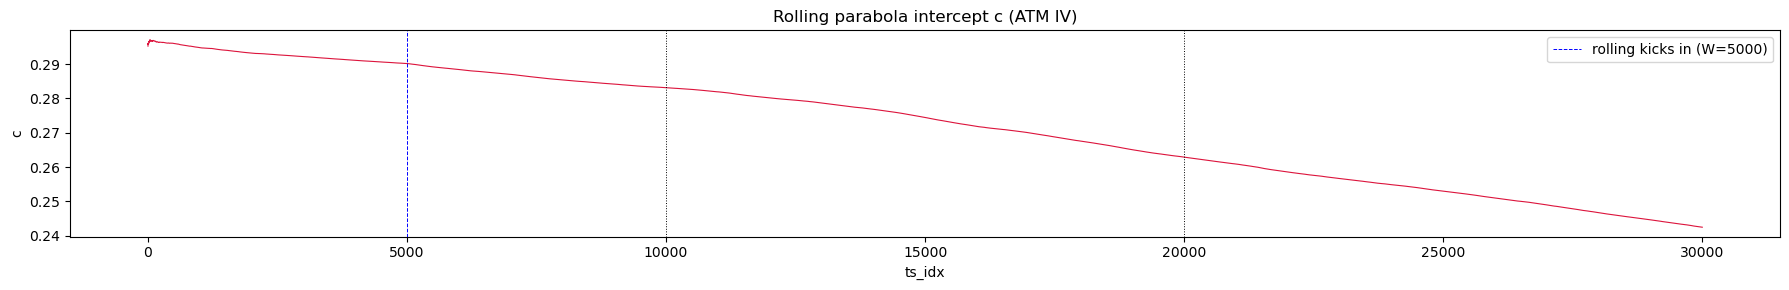

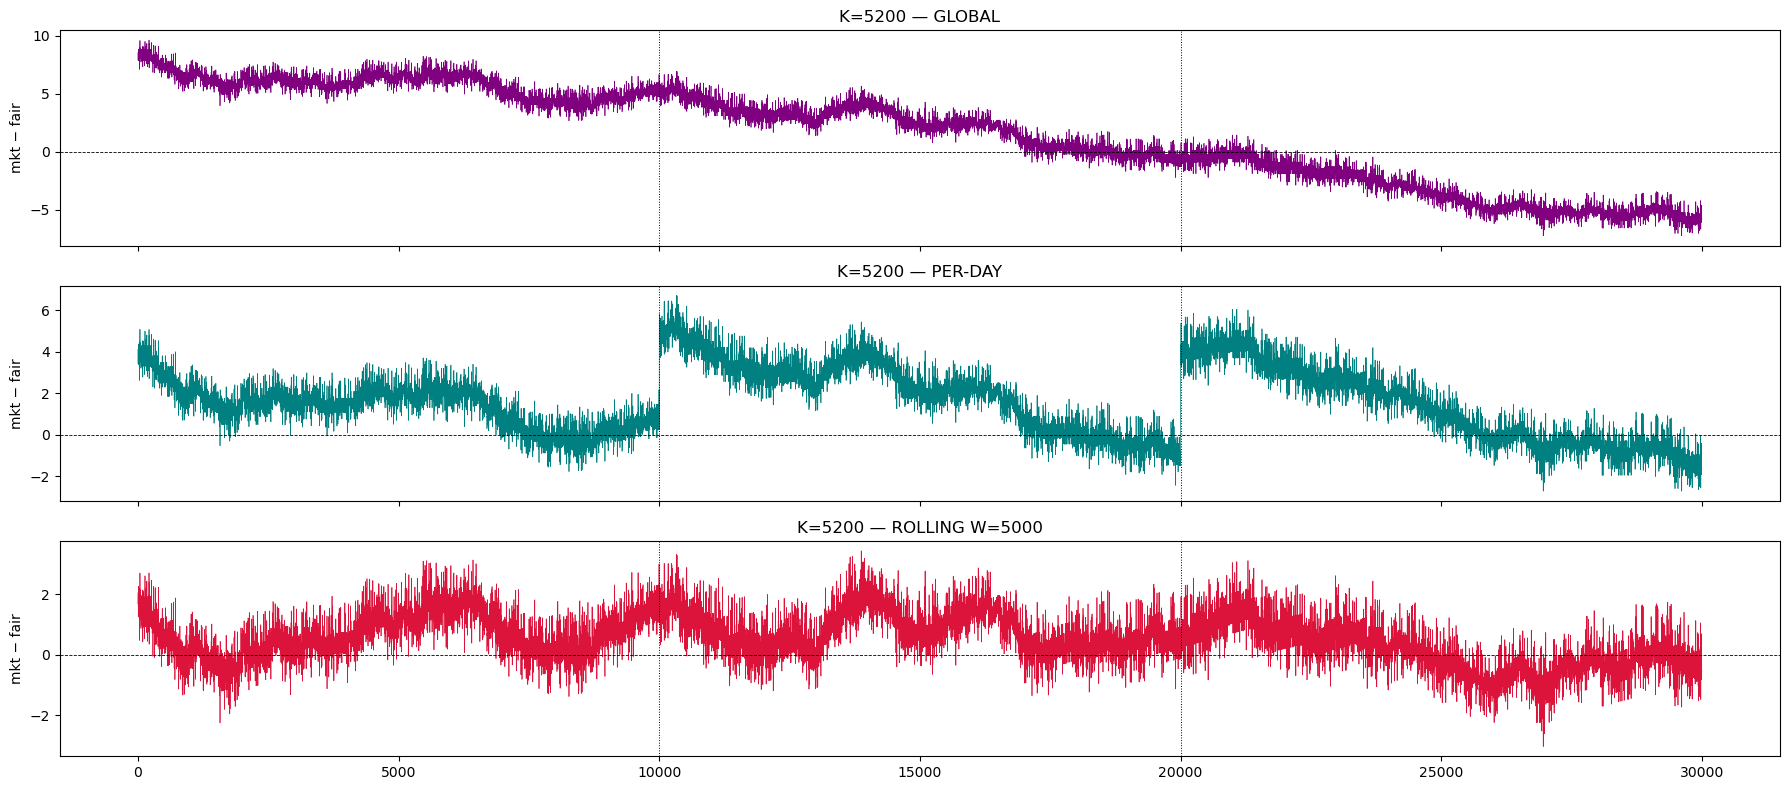

K=5200 price_dev std: global=4.118  per-day=1.638  rolling=0.786
K=5200 price_dev mean: global=+1.611 per-day=+1.572 rolling=+0.526


In [24]:
# map rolling coeffs back to opts_clean rows by ts_idx
opts_clean = opts_clean.drop(columns=['a_r','b_r','c_r'], errors='ignore')
coeffs_df = pd.DataFrame(coeffs_roll, index=full_idx, columns=['a_r','b_r','c_r'])
opts_clean = opts_clean.merge(coeffs_df, left_on='ts_idx', right_index=True, how='left')

opts_clean['iv_fit_r'] = (opts_clean['a_r'] * opts_clean['log_moneyness']**2
                        + opts_clean['b_r'] * opts_clean['log_moneyness']
                        + opts_clean['c_r'])
opts_clean['iv_resid_r'] = opts_clean['iv'] - opts_clean['iv_fit_r']
opts_clean['fair_price_r'] = opts_clean.apply(
    lambda r: bs_call(r['spot'], r['strike'], r['tte'], r['iv_fit_r']), axis=1)
opts_clean['price_dev_r'] = opts_clean['mid_price'] - opts_clean['fair_price_r']

# plot ATM IV intercept (c) over time
fig, ax = plt.subplots(figsize=(18,3))
ax.plot(full_idx, coeffs_df['c_r'], color='crimson', lw=0.8)
for x in [10000, 20000]:
    ax.axvline(x, color='k', ls=':', lw=0.7)
ax.axvline(W, color='blue', ls='--', lw=0.7, label=f'rolling kicks in (W={W})')
ax.set_title('Rolling parabola intercept c (ATM IV)')
ax.set_xlabel('ts_idx'); ax.set_ylabel('c'); ax.legend()
plt.tight_layout(); plt.show()

# compare global / per-day / rolling for K=5200
fig, axes = plt.subplots(3, 1, figsize=(18, 8), sharex=True)
sub = (opts_clean[opts_clean['strike']==5200]
       .sort_values(['day','timestamp']).reset_index(drop=True))
for ax, col, title, color in [
    (axes[0], 'price_dev',    'GLOBAL',   'purple'),
    (axes[1], 'price_dev_pd', 'PER-DAY',  'teal'),
    (axes[2], 'price_dev_r',  f'ROLLING W={W}', 'crimson'),
]:
    ax.plot(sub.index, sub[col], lw=0.5, color=color)
    ax.axhline(0, color='k', lw=0.6, ls='--')
    for xv in [10000, 20000]:
        ax.axvline(xv, color='k', ls=':', lw=0.7)
    ax.set_title(f'K=5200 — {title}'); ax.set_ylabel('mkt − fair')
plt.tight_layout(); plt.show()

print(f'K=5200 price_dev std: global={sub.price_dev.std():.3f}  per-day={sub.price_dev_pd.std():.3f}  rolling={sub.price_dev_r.std():.3f}')
print(f'K=5200 price_dev mean: global={sub.price_dev.mean():+.3f} per-day={sub.price_dev_pd.mean():+.3f} rolling={sub.price_dev_r.mean():+.3f}')

## Live-engine compatibility test: incremental EWMA sums

Goal: prove we can run the smile fit inside `engine_ab.py` with only **8 floats of state** (Σ1, Σx, Σx², Σx³, Σx⁴, Σy, Σxy, Σx²y), no raw history.

Approach: simulate the trader. At each `ts_idx`:
1. Decay state by γ.
2. Add this tick's contributions (one (log_moneyness, iv) point per voucher).
3. Solve 3×3 normal equations → fresh (a, b, c).

Compare coeff trajectory + price_dev to the rolling-window fit from cell above. If they track closely, the live-engine version works without persisting any raw data.

`γ` controls memory. γ=1 → expanding window (all history equal weight). γ=0.9999 → ~6931-tick half-life (similar to W=5000 rolling).

live coeffs at t=10:    a=8.3862, b=+0.0019, c=0.2958
live coeffs at t=5000:   a=8.8462, b=+0.0507, c=0.2873
live coeffs at t=29999: a=9.6157, b=-0.0650, c=0.2394


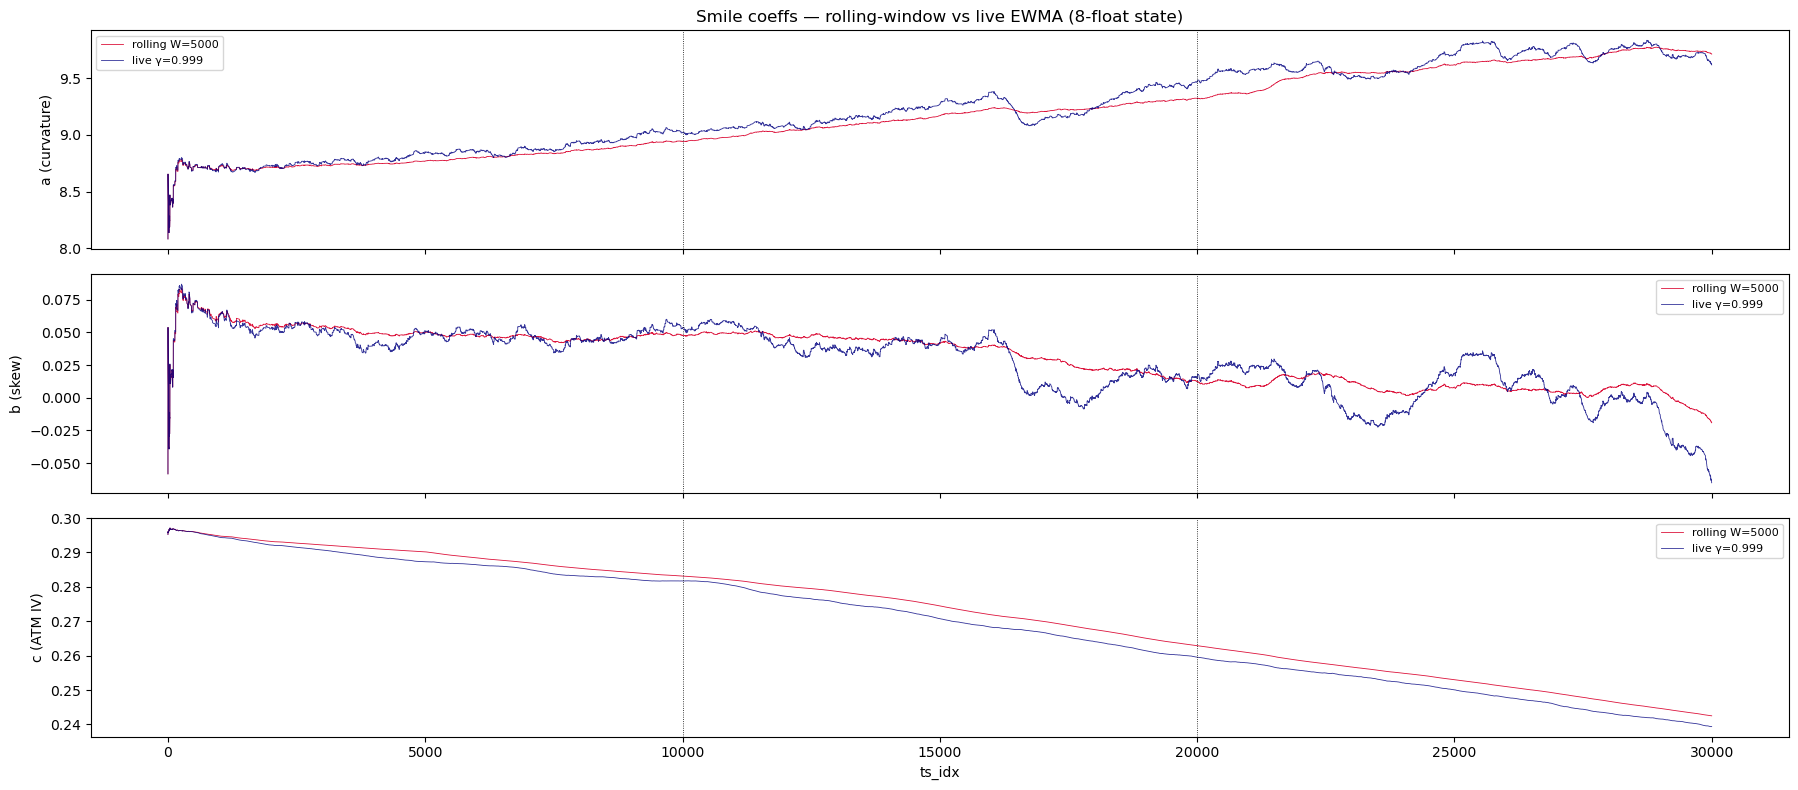


coeff agreement (t >= W):
  a (curvature)   mean diff = +5.9237e-02   std diff = 6.3912e-02
  b (skew)        mean diff = -3.7485e-03   std diff = 1.2513e-02
  c (ATM IV)      mean diff = -2.8678e-03   std diff = 6.4597e-04


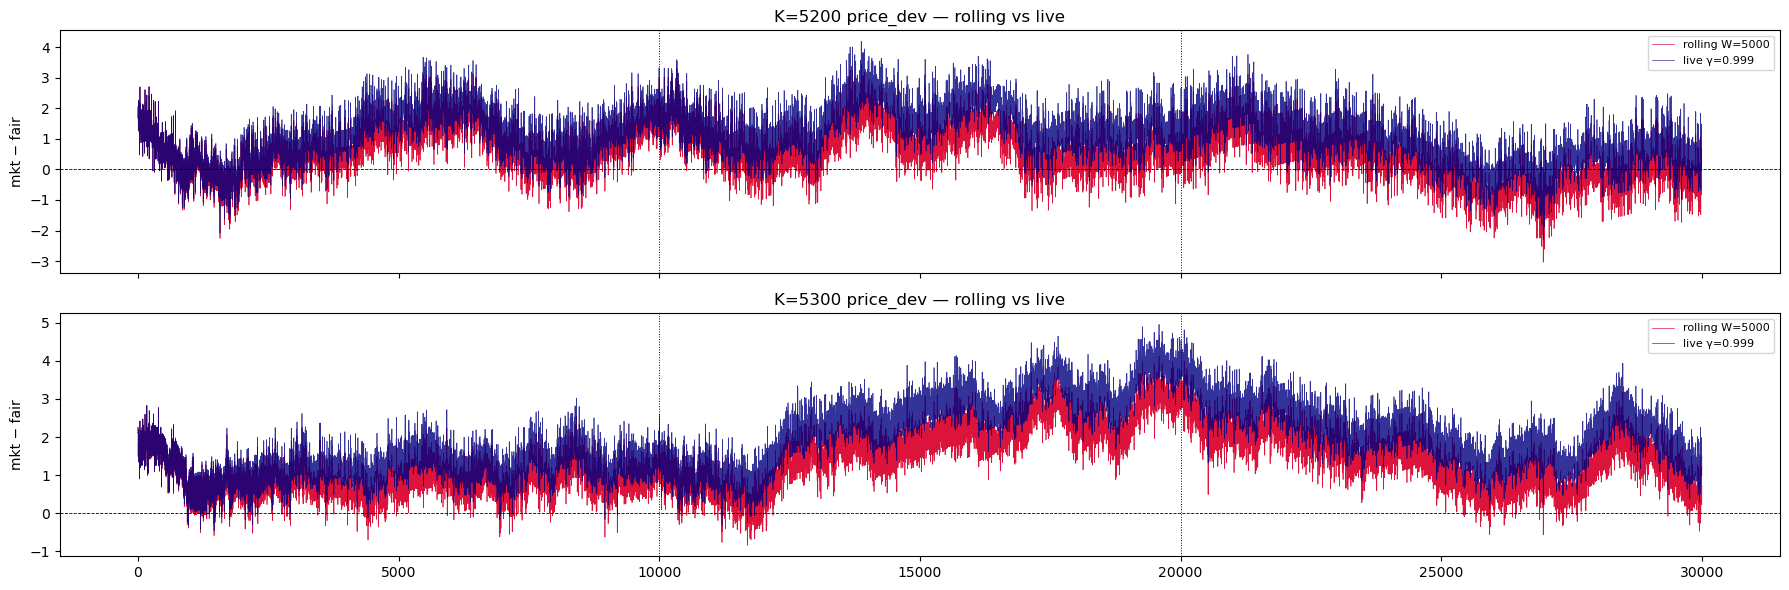


K=5200 post-warmup:
  rolling: mean=+0.550  std=0.810
  live   : mean=+1.222  std=0.783
  corr(rolling, live) = 0.9815

K=5300 post-warmup:
  rolling: mean=+1.453  std=0.776
  live   : mean=+2.119  std=0.865
  corr(rolling, live) = 0.9898


In [32]:
# Live-engine simulation — what the trader can actually compute with 8 floats of state.

GAMMA = 0.999  # decay per tick. 1.0 = expanding window. 0.9999 ≈ 6931-tick half-life.

# Per-ts contributions already exist from the rolling-fit cell as `per_ts` indexed on full_idx.
arr = per_ts.reindex(full_idx, fill_value=0.0)[agg_cols].values   # shape (T, 8)
T_ = len(arr)

state = np.zeros(8)
coeffs_live = np.full((T_, 3), np.nan)   # (a, b, c)

for t in range(T_):
    state = GAMMA * state + arr[t]
    s = state
    M_t = np.array([[s[0], s[1], s[2]],
                    [s[1], s[2], s[3]],
                    [s[2], s[3], s[4]]])
    B_t = np.array([s[5], s[6], s[7]])
    try:
        sol = np.linalg.solve(M_t, B_t)   # [c, b, a]
        coeffs_live[t] = sol[::-1]
    except np.linalg.LinAlgError:
        pass   # leave NaN for early ticks where system is singular

print(f'live coeffs at t=10:    a={coeffs_live[10,0]:.4f}, b={coeffs_live[10,1]:+.4f}, c={coeffs_live[10,2]:.4f}')
print(f'live coeffs at t={W}:   a={coeffs_live[W,0]:.4f}, b={coeffs_live[W,1]:+.4f}, c={coeffs_live[W,2]:.4f}')
print(f'live coeffs at t={T_-1}: a={coeffs_live[-1,0]:.4f}, b={coeffs_live[-1,1]:+.4f}, c={coeffs_live[-1,2]:.4f}')

# Compare coeff trajectories: rolling W vs live EWMA.
fig, axes = plt.subplots(3, 1, figsize=(18, 8), sharex=True)
labels = ['a (curvature)', 'b (skew)', 'c (ATM IV)']
for i, ax in enumerate(axes):
    ax.plot(full_idx, coeffs_roll[:, i], lw=0.6, color='crimson', label=f'rolling W={W}')
    ax.plot(full_idx, coeffs_live[:, i], lw=0.6, color='navy', alpha=0.8, label=f'live γ={GAMMA}')
    for x in [10000, 20000]:
        ax.axvline(x, color='k', ls=':', lw=0.6)
    ax.set_ylabel(labels[i]); ax.legend(fontsize=8)
axes[0].set_title('Smile coeffs — rolling-window vs live EWMA (8-float state)')
axes[-1].set_xlabel('ts_idx')
plt.tight_layout(); plt.show()

# Quantitative agreement post-warmup.
print('\ncoeff agreement (t >= W):')
for i, lbl in enumerate(labels):
    diff = coeffs_live[W:, i] - coeffs_roll[W:, i]
    print(f'  {lbl:14s}  mean diff = {np.nanmean(diff):+.4e}   std diff = {np.nanstd(diff):.4e}')

# Apply live coeffs back to opts_clean → fair price → price_dev → compare.
opts_live = opts_clean.copy()
opts_live = opts_live.drop(columns=['a_l','b_l','c_l'], errors='ignore').merge(
    pd.DataFrame(coeffs_live, index=full_idx, columns=['a_l','b_l','c_l']),
    left_on='ts_idx', right_index=True, how='left',
)
opts_live['iv_fit_l'] = (opts_live['a_l']*opts_live['log_moneyness']**2
                       + opts_live['b_l']*opts_live['log_moneyness']
                       + opts_live['c_l'])
opts_live['fair_price_l'] = opts_live.apply(
    lambda r: bs_call(r['spot'], r['strike'], r['tte'], r['iv_fit_l']), axis=1)
opts_live['price_dev_l'] = opts_live['mid_price'] - opts_live['fair_price_l']

# Plot price_dev for K=5200 + K=5300, rolling vs live.
fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True)
for ax, K in zip(axes, [5200, 5300]):
    sub = (opts_live[opts_live['strike']==K]
           .sort_values(['day','timestamp']).reset_index(drop=True))
    ax.plot(sub.index, sub['price_dev_r'], lw=0.5, color='crimson', label=f'rolling W={W}')
    ax.plot(sub.index, sub['price_dev_l'], lw=0.5, color='navy', alpha=0.8, label=f'live γ={GAMMA}')
    ax.axhline(0, color='k', lw=0.6, ls='--')
    for xv in [10000, 20000]:
        ax.axvline(xv, color='k', ls=':', lw=0.7)
    ax.set_title(f'K={K} price_dev — rolling vs live'); ax.set_ylabel('mkt − fair')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Stats post-warmup.
for K in [5200, 5300]:
    post = opts_live[(opts_live['strike']==K) & (opts_live['ts_idx']>=W)]
    print(f'\nK={K} post-warmup:')
    print(f'  rolling: mean={post.price_dev_r.mean():+.3f}  std={post.price_dev_r.std():.3f}')
    print(f'  live   : mean={post.price_dev_l.mean():+.3f}  std={post.price_dev_l.std():.3f}')
    corr = post[['price_dev_r','price_dev_l']].corr().iloc[0,1]
    print(f'  corr(rolling, live) = {corr:.4f}')


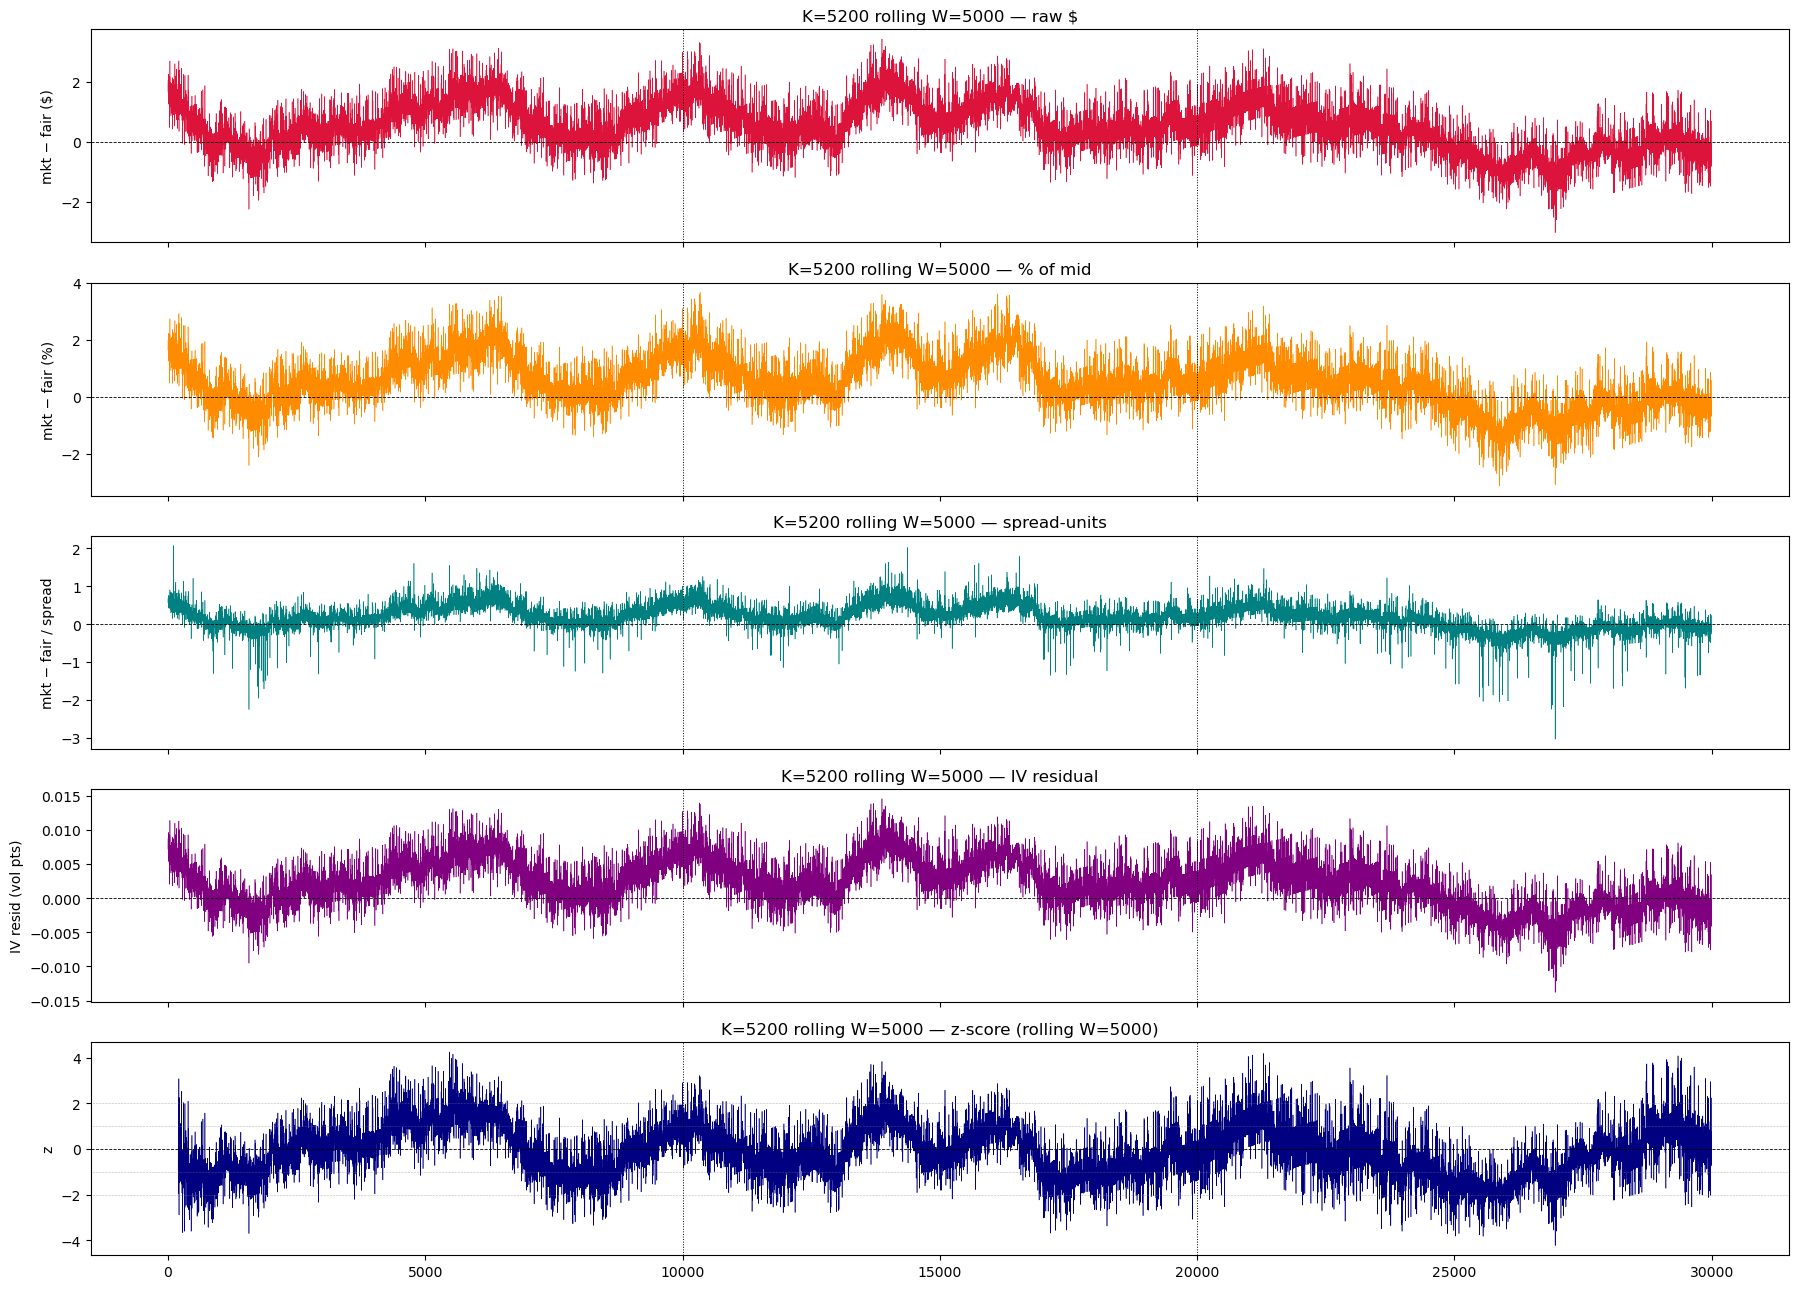

K=5200 (post-warmup):
  raw $   : mean=+0.550  std=0.810
  % mid   : mean=+0.5771%  std=0.8927%
  spreads : mean=+0.192  std=0.311
  IV pts  : mean=+0.0023  std=0.0035
  z-score : mean=-0.126  std=1.098  (~0/1 if rolling z healthy)


In [31]:
# rescale price_dev_r in useful units
sp = prices[prices['product'].str.startswith('VEV_')][['day','timestamp','product','ask_price_1','bid_price_1']].copy()
sp['spread'] = sp['ask_price_1'] - sp['bid_price_1']
sp['strike'] = sp['product'].str.extract(r'(\d+)$').astype(int)
opts_clean = opts_clean.drop(columns=['spread'], errors='ignore').merge(
    sp[['day','timestamp','strike','spread']], on=['day','timestamp','strike'], how='left')

opts_clean['dev_pct']    = 100 * opts_clean['price_dev_r'] / opts_clean['mid_price']
opts_clean['dev_spread'] = opts_clean['price_dev_r'] / opts_clean['spread'].replace(0, np.nan)
opts_clean['dev_iv']     = opts_clean['iv_resid_r']

# rolling z-score per strike (window W in ts)
def rolling_z(df_strike):
    df_strike = df_strike.sort_values('ts_idx').copy()
    s = df_strike['price_dev_r']
    df_strike['dev_z'] = (s - s.rolling(W, min_periods=200).mean()) / s.rolling(W, min_periods=200).std()
    return df_strike
opts_clean = opts_clean.drop(columns=['dev_z'], errors='ignore')
opts_clean = opts_clean.groupby('strike', group_keys=False).apply(rolling_z)

fig, axes = plt.subplots(5, 1, figsize=(18, 13), sharex=True)
sub = (opts_clean[opts_clean['strike']==5200]
       .sort_values(['day','timestamp']).reset_index(drop=True))

for ax, col, title, ylabel, color in [
    (axes[0], 'price_dev_r', 'raw $',          'mkt − fair ($)',        'crimson'),
    (axes[1], 'dev_pct',     '% of mid',       'mkt − fair (%)',        'darkorange'),
    (axes[2], 'dev_spread',  'spread-units',   'mkt − fair / spread',   'teal'),
    (axes[3], 'dev_iv',      'IV residual',    'IV resid (vol pts)',    'purple'),
    (axes[4], 'dev_z',       f'z-score (rolling W={W})', 'z',           'navy'),
]:
    ax.plot(sub.index, sub[col], lw=0.4, color=color)
    ax.axhline(0, color='k', lw=0.6, ls='--')
    if col == 'dev_z':
        for h in [-2, -1, 1, 2]:
            ax.axhline(h, color='grey', lw=0.4, ls=':')
    for xv in [10000, 20000]:
        ax.axvline(xv, color='k', ls=':', lw=0.7)
    ax.set_title(f'K=5200 rolling W={W} — {title}'); ax.set_ylabel(ylabel)
plt.tight_layout(); plt.show()

post = sub[sub['ts_idx']>=W]
print('K=5200 (post-warmup):')
print(f'  raw $   : mean={post.price_dev_r.mean():+.3f}  std={post.price_dev_r.std():.3f}')
print(f'  % mid   : mean={post.dev_pct.mean():+.4f}%  std={post.dev_pct.std():.4f}%')
print(f'  spreads : mean={post.dev_spread.mean():+.3f}  std={post.dev_spread.std():.3f}')
print(f'  IV pts  : mean={post.dev_iv.mean():+.4f}  std={post.dev_iv.std():.4f}')
print(f'  z-score : mean={post.dev_z.mean():+.3f}  std={post.dev_z.std():.3f}  (~0/1 if rolling z healthy)')

## Stationarity + mean-reversion tests on `price_dev_r` (K=5200)

- **ADF**: H0 = unit root (non-stationary). Reject (p<0.05) → stationary.
- **KPSS**: H0 = stationary. Fail to reject → consistent with stationarity.
- **AR(1)**: x_{t+1} = φ·x_t + ε. φ<1 → mean-reverting. Half-life = -ln(2)/ln(φ).
- **Hurst exponent**: <0.5 mean-reverting, =0.5 random walk, >0.5 trending.

Drop warmup region (t < W) before testing.

series length (post-warmup): 25000
mean=+0.5505  std=0.8102  min=-3.036  max=+3.436

ADF: stat=-2.601, p=9.27e-02, crit5%=-2.862
  → non-stationary
KPSS: stat=10.875, p=0.010, crit5%=0.463
  → NON-stationary (reject H0)

AR(1): φ=0.78565  (intercept=+0.1179)
  half-life = 2.9 ticks  (φ<1 → mean-reverting)

Hurst exponent: H=0.021
  → mean-reverting


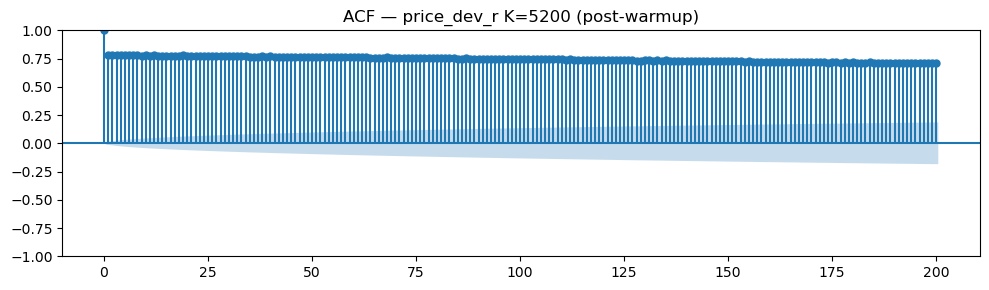

In [27]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

ser = (opts_clean[(opts_clean['strike']==5200) & (opts_clean['ts_idx']>=W)]
       .sort_values('ts_idx')['price_dev_r']
       .dropna().values)
print(f'series length (post-warmup): {len(ser)}')
print(f'mean={ser.mean():+.4f}  std={ser.std():.4f}  min={ser.min():+.3f}  max={ser.max():+.3f}\n')

# ADF
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(ser, autolag='AIC')
print(f'ADF: stat={adf_stat:.3f}, p={adf_p:.2e}, crit5%={adf_crit["5%"]:.3f}')
print(f'  → {"STATIONARY (reject unit root)" if adf_p<0.05 else "non-stationary"}')

# KPSS
kpss_stat, kpss_p, _, kpss_crit = kpss(ser, regression='c', nlags='auto')
print(f'KPSS: stat={kpss_stat:.3f}, p={kpss_p:.3f}, crit5%={kpss_crit["5%"]:.3f}')
print(f'  → {"stationary" if kpss_p>0.05 else "NON-stationary (reject H0)"}')

# AR(1)
x_t   = ser[:-1]
x_t1  = ser[1:]
phi, intercept = np.polyfit(x_t, x_t1, 1)
half_life = -np.log(2) / np.log(phi) if 0 < phi < 1 else np.nan
print(f'\nAR(1): φ={phi:.5f}  (intercept={intercept:+.4f})')
print(f'  half-life = {half_life:.1f} ticks  (φ<1 → mean-reverting)')

# Hurst (R/S, simple log-log fit)
def hurst(ts, lags=range(2, 100)):
    tau = [np.std(ts[lag:] - ts[:-lag]) for lag in lags]
    return np.polyfit(np.log(lags), np.log(tau), 1)[0]
H = hurst(ser)
print(f'\nHurst exponent: H={H:.3f}')
print(f'  → {"mean-reverting" if H<0.45 else "random-walk-ish" if H<0.55 else "trending"}')

# ACF plot
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots(figsize=(10,3))
plot_acf(ser, lags=200, ax=ax)
ax.set_title('ACF — price_dev_r K=5200 (post-warmup)')
plt.tight_layout(); plt.show()

N=   1  n=25000  Hurst=+0.078  φ=+0.786  half-life=2.87 (in N-tick units)
N=   2  n=12500  Hurst=+0.082  φ=+0.782  half-life=2.81 (in N-tick units)
N=   5  n= 5000  Hurst=+0.088  φ=+0.786  half-life=2.88 (in N-tick units)
N=  10  n= 2500  Hurst=+0.097  φ=+0.786  half-life=2.88 (in N-tick units)
N=  25  n= 1000  Hurst=+0.099  φ=+0.773  half-life=2.69 (in N-tick units)
N=  50  n=  500  Hurst=+0.208  φ=+0.745  half-life=2.35 (in N-tick units)
N= 100  n=  250  Hurst=+0.297  φ=+0.725  half-life=2.16 (in N-tick units)


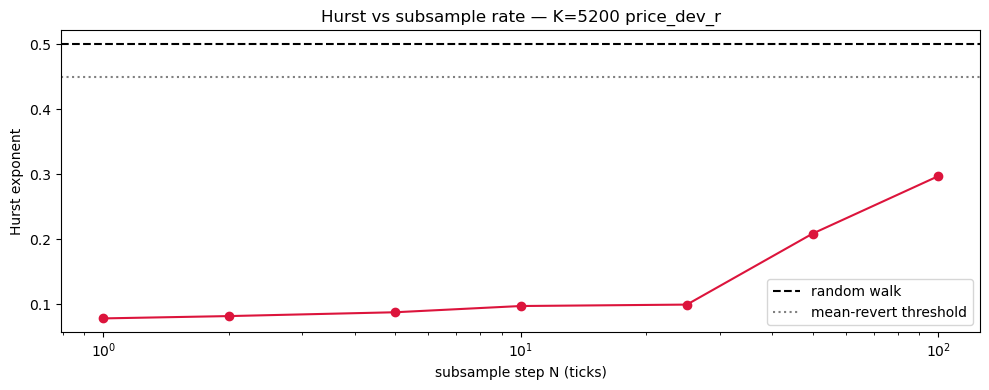

In [28]:
# Hurst at multiple sampling rates
# microstructure noise dies out as you subsample → if H rises toward 0.5, was noise.
# if H stays low across N → real mean-reversion at all scales.

def hurst(ts, lags=None):
    if lags is None:
        lags = range(2, max(20, len(ts)//50))
    tau = [np.std(ts[lag:] - ts[:-lag]) for lag in lags]
    return np.polyfit(np.log(list(lags)), np.log(tau), 1)[0]

Ns = [1, 2, 5, 10, 25, 50, 100, 200, 500]
results = []
for N in Ns:
    sub_ser = ser[::N]
    if len(sub_ser) < 200:
        continue
    H = hurst(sub_ser)
    # also AR(1) phi at this scale
    if len(sub_ser) > 10:
        phi_n, _ = np.polyfit(sub_ser[:-1], sub_ser[1:], 1)
        hl_n = -np.log(2)/np.log(phi_n) if 0<phi_n<1 else np.nan
    else:
        phi_n, hl_n = np.nan, np.nan
    results.append((N, len(sub_ser), H, phi_n, hl_n))
    print(f'N={N:4d}  n={len(sub_ser):5d}  Hurst={H:+.3f}  φ={phi_n:+.3f}  half-life={hl_n:.2f} (in N-tick units)')

# plot
res = np.array([(r[0], r[2]) for r in results])
fig, ax = plt.subplots(figsize=(10,4))
ax.semilogx(res[:,0], res[:,1], 'o-', color='crimson')
ax.axhline(0.5, color='k', ls='--', label='random walk')
ax.axhline(0.45, color='grey', ls=':', label='mean-revert threshold')
ax.set_xlabel('subsample step N (ticks)')
ax.set_ylabel('Hurst exponent')
ax.set_title('Hurst vs subsample rate — K=5200 price_dev_r')
ax.legend(); plt.tight_layout(); plt.show()

z-series length: 25000
mean=-0.1260  std=1.0981  min=-4.24  max=+4.26

ADF: stat=-3.453, p=9.27e-03, crit5%=-2.862
  → STATIONARY
KPSS: stat=2.708, p=0.010, crit5%=0.463
  → NON-stationary

AR(1): φ=0.70839  intercept=-0.0368
  half-life = 2.01 ticks

Hurst: H=0.074  → mean-reverting

Hurst at subsample rates:
  N=   1  n=25000  H=+0.074  φ=+0.708
  N=   2  n=12500  H=+0.077  φ=+0.702
  N=   5  n= 5000  H=+0.083  φ=+0.709
  N=  10  n= 2500  H=+0.092  φ=+0.712
  N=  25  n= 1000  H=+0.092  φ=+0.693
  N=  50  n=  500  H=+0.210  φ=+0.673
  N= 100  n=  250  H=+0.312  φ=+0.655


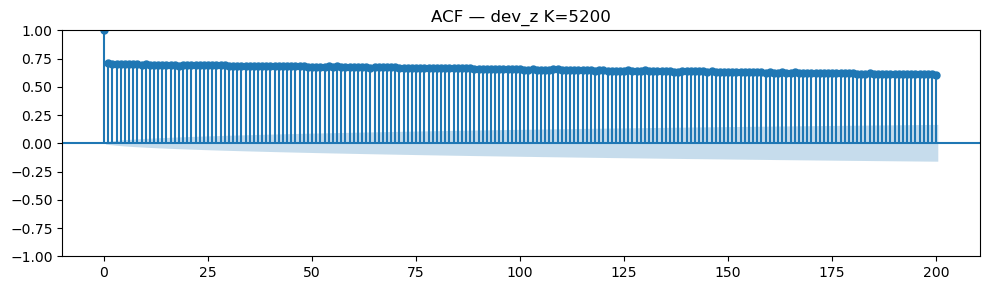

In [29]:
# stationarity + mean-reversion on z-score series
ser_z = (opts_clean[(opts_clean['strike']==5200) & (opts_clean['ts_idx']>=W)]
         .sort_values('ts_idx')['dev_z']
         .dropna().values)
print(f'z-series length: {len(ser_z)}')
print(f'mean={ser_z.mean():+.4f}  std={ser_z.std():.4f}  min={ser_z.min():+.2f}  max={ser_z.max():+.2f}\n')

adf_stat, adf_p, _, _, adf_crit, _ = adfuller(ser_z, autolag='AIC')
print(f'ADF: stat={adf_stat:.3f}, p={adf_p:.2e}, crit5%={adf_crit["5%"]:.3f}')
print(f'  → {"STATIONARY" if adf_p<0.05 else "non-stationary"}')

kpss_stat, kpss_p, _, kpss_crit = kpss(ser_z, regression='c', nlags='auto')
print(f'KPSS: stat={kpss_stat:.3f}, p={kpss_p:.3f}, crit5%={kpss_crit["5%"]:.3f}')
print(f'  → {"stationary" if kpss_p>0.05 else "NON-stationary"}')

phi_z, intercept_z = np.polyfit(ser_z[:-1], ser_z[1:], 1)
hl_z = -np.log(2)/np.log(phi_z) if 0<phi_z<1 else np.nan
print(f'\nAR(1): φ={phi_z:.5f}  intercept={intercept_z:+.4f}')
print(f'  half-life = {hl_z:.2f} ticks')

H_z = hurst(ser_z)
print(f'\nHurst: H={H_z:.3f}  → {"mean-reverting" if H_z<0.45 else "random walk" if H_z<0.55 else "trending"}')

# subsample Hurst for z-score too
print('\nHurst at subsample rates:')
for N in [1, 2, 5, 10, 25, 50, 100, 200, 500]:
    s2 = ser_z[::N]
    if len(s2) < 200: continue
    H_n = hurst(s2)
    phi_n, _ = np.polyfit(s2[:-1], s2[1:], 1)
    print(f'  N={N:4d}  n={len(s2):5d}  H={H_n:+.3f}  φ={phi_n:+.3f}')

fig, ax = plt.subplots(figsize=(10,3))
plot_acf(ser_z, lags=200, ax=ax)
ax.set_title('ACF — dev_z K=5200')
plt.tight_layout(); plt.show()